In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## Ex08
Сделай всё необходимое, чтобы получить график как на примере:
- Анализируй только пользователей, без админов.
- Учитывай только логи из таблицы checker со статусом ready.
- Палитру выбери на свой вкус.
- linewidth = 3.
- Фон графика — серый.
- Высота — 10, ширина — в 1.5 раза больше высоты.
- Размер шрифта заголовка — 30.
- Размер шрифта подписей осей — 15.
- В конце блокнота добавь markdown-ячейку с вопросами (смотри только на график):
    - «Какой пользователь почти всё время был лидером по числу коммитов?» Ответ: user_*.
    - «Какой пользователь был лидером лишь недолгое время?» Ответ: user_*.

In [2]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [3]:
commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp, numTrials
    FROM checker
    WHERE uid LIKE 'user_%'
      AND status = 'ready'
      AND labname = 'project1'
    ORDER BY timestamp
    """,
    conn,
    parse_dates=["timestamp"]
)

commits.head()

,uid,timestamp,numTrials
0,user_4,2020-04-17 05:19:02.744528,1
1,user_4,2020-04-17 05:22:45.549397,2
2,user_4,2020-04-17 05:34:24.422370,3
3,user_4,2020-04-17 05:43:27.773992,4
4,user_4,2020-04-17 05:46:32.275104,5


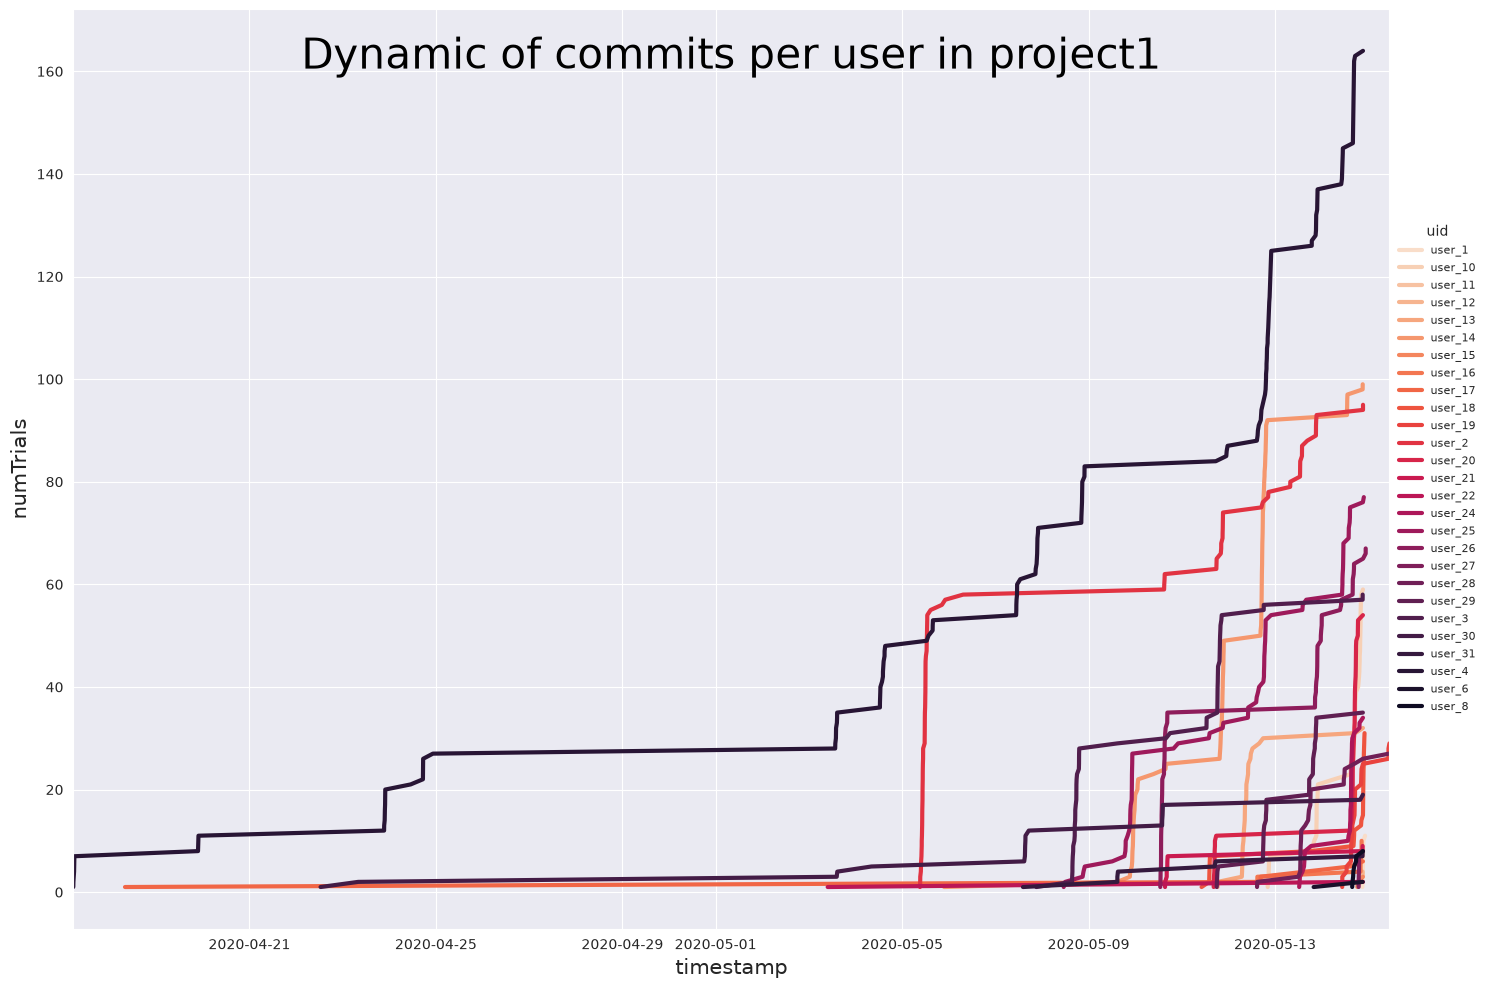

In [4]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(figsize=(15, 10))

uid_list = sorted(commits['uid'].unique())
palette = sns.color_palette('rocket_r', n_colors=len(uid_list))

sns.lineplot(
    data=commits,
    x='timestamp',
    y='numTrials',
    hue='uid',
    hue_order=uid_list,
    palette=palette,
    linewidth=3,
    ax=ax
)

ax.text(
    0.5, 0.97,
    'Dynamic of commits per user in project1',
    transform=ax.transAxes,
    fontsize=30,
    ha='center', va='top',
    color='black'
)

ax.set_xlabel('timestamp', fontsize=15)
ax.set_ylabel('numTrials', fontsize=15)
ax.set_xlim(commits['timestamp'].min(), commits['timestamp'].max())

ax.legend(bbox_to_anchor=(1.00, 0.5), loc='center left', fontsize=8, title='uid', frameon=False)

plt.tight_layout()
plt.show()

- «Какой пользователь почти всё время был лидером по числу коммитов?»
    - **user_4**.
- «Какой пользователь был лидером лишь недолгое время?»
    - **user_2**

In [5]:
conn.close()